In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ***1️⃣ Import Library & Load Dataset***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# Load Titanic dari seaborn
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# 2️⃣ Ukuran Data & Tipe ***Kolom***

In [3]:
print("Ukuran Dataset:", df.shape)
print("\nTipe Kolom:")
print(df.dtypes)

Ukuran Dataset: (891, 15)

Tipe Kolom:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


# ***3️⃣ Tangani Missing Value (dengan alasan)***

In [4]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Strategi:

age → isi dengan median (karena numerik & ada outlier)

embarked → isi dengan modus (kategorikal)

deck → drop (terlalu banyak missing)

In [5]:
# Isi age dengan median
df["age"].fillna(df["age"].median(), inplace=True)

# Isi embarked dengan modus
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

# Buang deck
df.drop(columns=["deck"], inplace=True)

print("\nMissing values setelah dibersihkan:")
print(df.isnull().sum())


Missing values setelah dibersihkan:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


/tmp/ipython-input-3232216160.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
/tmp/ipython-input-3232216160.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# ***4️⃣ Tangani Outlier (2 Kolom: age & fare)\***

Menggumnakan Metode IQR

In [7]:
def remove_outlier_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    bawah = Q1 - 1.5 * IQR
    atas = Q3 + 1.5 * IQR

    return data[(data[column] >= bawah) & (data[column] <= atas)]

df = remove_outlier_iqr(df, "age")
df = remove_outlier_iqr(df, "fare")

print("Ukuran setelah remove outlier:", df.shape)

Ukuran setelah remove outlier: (638, 14)


Alasan:


> Age & Fare punya distribusi skewed

> Banyak nilai ekstrem pada Fare

# ***5️⃣ Scaling Kolom Numerik***

In [8]:
scaler = StandardScaler()

numeric_cols = ["age", "fare", "sibsp", "parch"]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,-0.685003,0.762974,-0.377329,-0.761026,S,Third,man,True,Southampton,no,False
2,1,3,female,-0.205275,-0.450935,-0.377329,-0.690011,S,Third,woman,False,Southampton,yes,True
4,0,3,male,0.874111,-0.450935,-0.377329,-0.676860,S,Third,man,True,Southampton,no,True
5,0,3,male,0.034588,-0.450935,-0.377329,-0.633904,Q,Third,man,True,Queenstown,no,True
8,1,3,female,-0.085343,-0.450935,2.156733,-0.352475,S,Third,woman,False,Southampton,yes,False


# ***6️⃣ Visualisasi (Minimal 5)***

**📊 1. Survival**

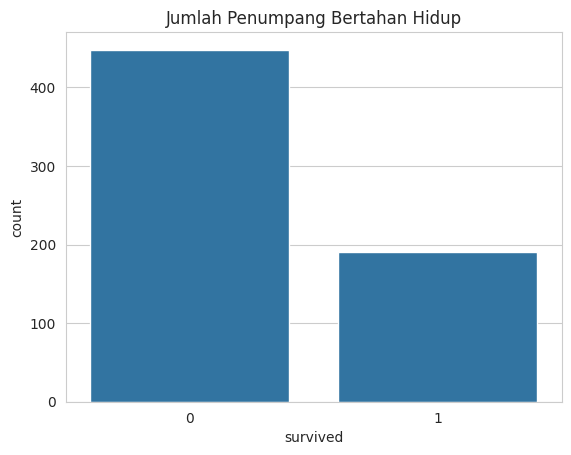

In [9]:
plt.figure()
sns.countplot(x="survived", data=df)
plt.title("Jumlah Penumpang Bertahan Hidup")
plt.show()

**📊 2. Survival berdasarkan Gender**

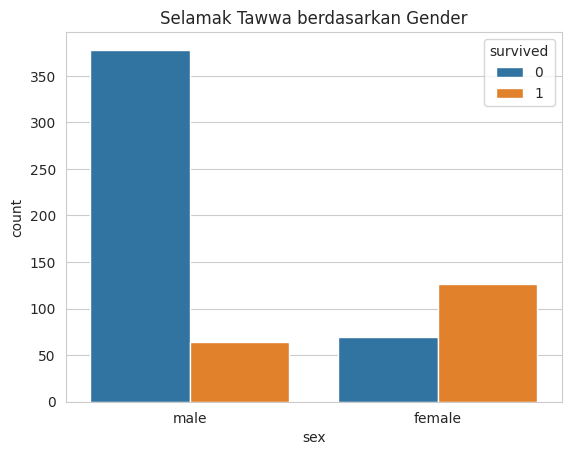

In [16]:
plt.figure()
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Selamak Tawwa berdasarkan Gender")
plt.show()

**📊 3. Distribusi Umur**

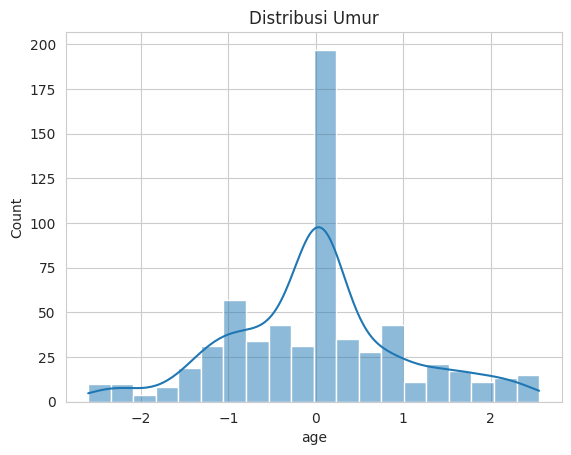

In [17]:
plt.figure()
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Distribusi Umur")
plt.show()

**📊 4. Fare vs Survival**

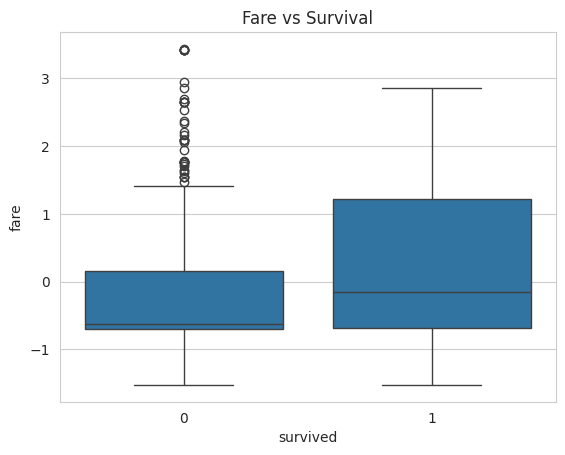

In [18]:
plt.figure()
sns.boxplot(x="survived", y="fare", data=df)
plt.title("Fare vs Survival")
plt.show()

**📊 5. Korelasi Heatmap**

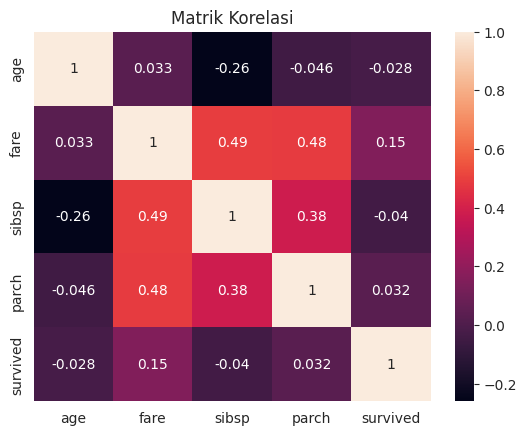

In [20]:
plt.figure()
sns.heatmap(df[numeric_cols + ["survived"]].corr(), annot=True)
plt.title("Matrik Korelasi")
plt.show()